In [2]:
from google.colab import files
uploaded = files.upload()

Saving energy_readings.parquet to energy_readings.parquet
Saving sensors_meta_1.json to sensors_meta_1.json
Saving sensors_meta_2.csv to sensors_meta_2.csv
Saving sensors_meta_3.csv to sensors_meta_3.csv


In [3]:
!pip install pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import min, max, avg, count, col, to_timestamp, to_date, date_format, hour, countDistinct
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("3LD").getOrCreate()
print("Spark sesija sėkmingai inicializuota.")

df_main = spark.read.parquet("energy_readings.parquet")
df_main.show(5, truncate=False)
df_main.printSchema()

Spark sesija sėkmingai inicializuota.
+---------+-----------------------------+------------------+
|Sensor_ID|Timestamp                    |Consumption_kWh   |
+---------+-----------------------------+------------------+
|1260     |2026-01-01 00:00:00.000000000|20.037824106534273|
|1458     |2026-01-01 00:00:02.384640953|18.18813289672814 |
|1216     |2026-01-01 00:00:04.769281907|21.61988252732715 |
|1436     |2026-01-01 00:00:07.153922861|18.25179419347746 |
|1259     |2026-01-01 00:00:09.538563815|21.932887745312556|
+---------+-----------------------------+------------------+
only showing top 5 rows
root
 |-- Sensor_ID: long (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- Consumption_kWh: double (nullable = true)



In [4]:
from pyspark.sql.functions import countDistinct, avg, min, max, to_timestamp, col

# Nuskaitytas pagrindinis failas
df_main = spark.read.parquet("energy_readings.parquet")

# Timestamp paverčiam į timestamp tipą, kad galėtume tvarkingai dirbti su datomis
df_main = df_main.withColumn("Timestamp_ts", to_timestamp(col("Timestamp")))

# Suskaičiuojam reikalingas reikšmes
results = df_main.agg(
    countDistinct("Sensor_ID").alias("unique_sensors"),
    avg("Consumption_kWh").alias("avg_consumption"),
    min("Timestamp_ts").alias("min_timestamp"),
    max("Timestamp_ts").alias("max_timestamp")
).collect()[0]

# Bendras įrašų skaičius
total_records = df_main.count()

# Ištraukiam rezultatus
start_date = str(results["min_timestamp"])[:10]
end_date = str(results["max_timestamp"])[:10]
unique_sensors = results["unique_sensors"]
avg_consumption = results["avg_consumption"]

# Išvedam atsakymus
print("Atsakymas 1:", total_records)
print("Atsakymas 2:", start_date)
print("Atsakymas 3:", end_date)
print("Atsakymas 4:", unique_sensors)
print("Atsakymas 5:", avg_consumption)

Atsakymas 1: 2500000
Atsakymas 2: 2026-01-01
Atsakymas 3: 2026-03-11
Atsakymas 4: 478
Atsakymas 5: 20.104432564058285


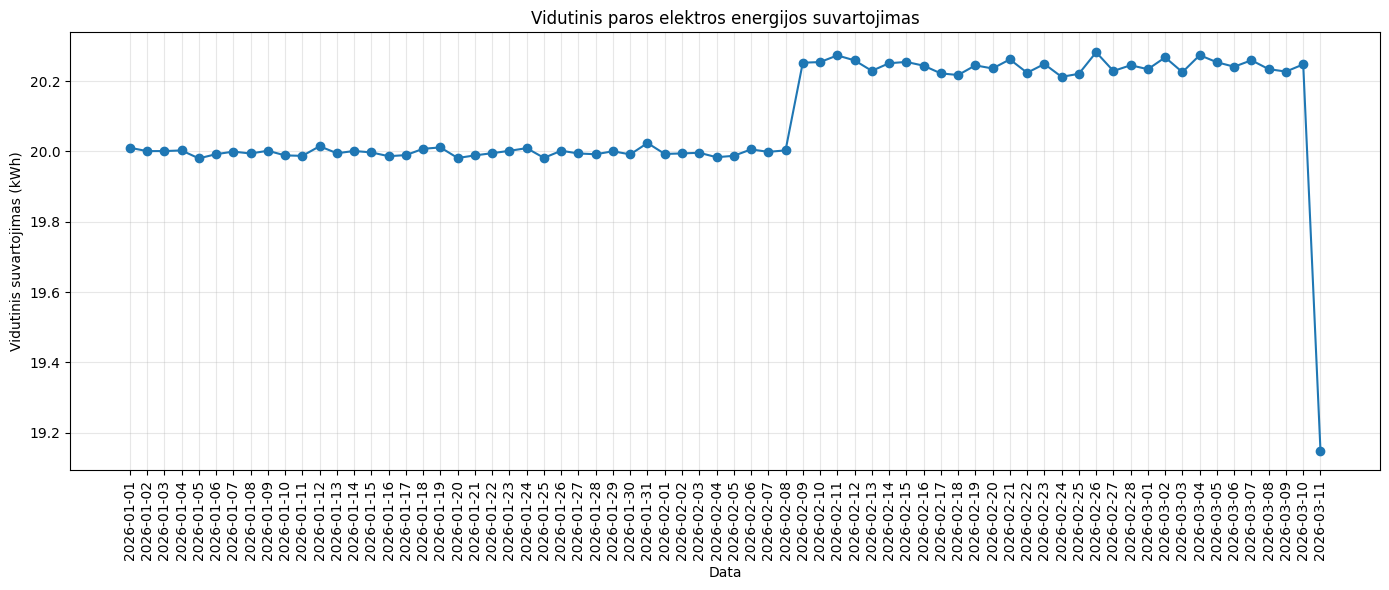

In [7]:
from pyspark.sql.functions import col, to_timestamp, date_format, avg
import matplotlib.pyplot as plt

# 1. Nuskaitymas
df_main = spark.read.parquet("energy_readings.parquet")

# 2. Timestamp pavertimas į timestamp tipą
df_main = df_main.withColumn("Timestamp_ts", to_timestamp(col("Timestamp")))

# 3. Iš timestamp pasidarom dienos stulpelį ir skaičiuojam dienos vidurkį
df_daily = (
    df_main
    .withColumn("Day", date_format(col("Timestamp_ts"), "yyyy-MM-dd"))
    .groupBy("Day")
    .agg(avg("Consumption_kWh").alias("Daily_Avg_Consumption"))
    .orderBy("Day")
)

# 4. Persikeliam į Pandas braižymui
daily_pd = df_daily.toPandas()

# 5. Braižom grafiką
plt.figure(figsize=(14, 6))
plt.plot(
    daily_pd["Day"],
    daily_pd["Daily_Avg_Consumption"],
    marker="o"
)

plt.xticks(rotation=90)
plt.title("Vidutinis paros elektros energijos suvartojimas")
plt.xlabel("Data")
plt.ylabel("Vidutinis suvartojimas (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 6. Išsaugom failą
plt.savefig("dienos_vidurkio_grafikas.png", dpi=300, bbox_inches="tight")

# 7. Parodom grafiką
plt.show()

In [8]:
from google.colab import files
files.download("dienos_vidurkio_grafikas.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

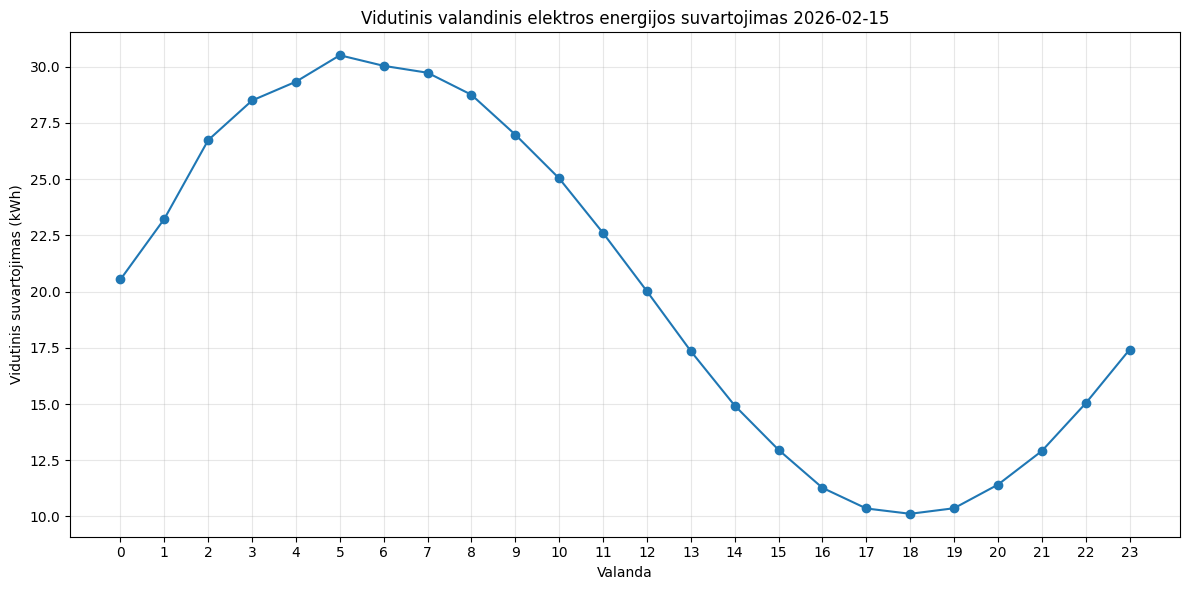

Didžiausias vidurkis buvo valandą: 5
Vidutinis suvartojimas tuo metu: 30.50688804311666


In [15]:
from pyspark.sql.functions import col, to_timestamp, to_date, hour, avg
import matplotlib.pyplot as plt

# 1. Nuskaitymas
df_main = spark.read.parquet("energy_readings.parquet")

# 2. Timestamp konvertavimas
df_main = df_main.withColumn("Timestamp_ts", to_timestamp(col("Timestamp")))

# 3. Pasirenkama diena
selected_day = "2026-02-15"

# 4. Filtravimas pagal dieną ir grupavimas pagal valandą
df_hourly = (
    df_main
    .withColumn("Date", to_date(col("Timestamp_ts")))
    .withColumn("Hour", hour(col("Timestamp_ts")))
    .filter(col("Date") == selected_day)
    .groupBy("Hour")
    .agg(avg("Consumption_kWh").alias("Hourly_Avg_Consumption"))
    .orderBy("Hour")
)

# 5. Į pandas braižymui
hourly_pd = df_hourly.toPandas()

# Jei nori būti tikras, kad bus visos 24 valandos nuo 0 iki 23,
# net jei kažkuriai valandai trūktų įrašų
all_hours = list(range(24))
hourly_pd = hourly_pd.set_index("Hour").reindex(all_hours).reset_index()
hourly_pd.columns = ["Hour", "Hourly_Avg_Consumption"]

# 6. Braižymas
plt.figure(figsize=(12, 6))
plt.plot(
    hourly_pd["Hour"],
    hourly_pd["Hourly_Avg_Consumption"],
    marker="o"
)

plt.xticks(range(24))
plt.title(f"Vidutinis valandinis elektros energijos suvartojimas {selected_day}")
plt.xlabel("Valanda")
plt.ylabel("Vidutinis suvartojimas (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 7. Išsaugojimas
plt.savefig("valandinis_suvartojimas_2026-02-15.png", dpi=300, bbox_inches="tight")
plt.show()

max_row = hourly_pd.loc[hourly_pd["Hourly_Avg_Consumption"].idxmax()]
print("Didžiausias vidurkis buvo valandą:", int(max_row["Hour"]))
print("Vidutinis suvartojimas tuo metu:", max_row["Hourly_Avg_Consumption"])

In [16]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import json

spark = SparkSession.builder.appName("3LD_meta").getOrCreate()

# sensors_meta_2.csv
df_meta2 = spark.read.option("header", True).option("sep", ";").csv("sensors_meta_2.csv")
print("sensors_meta_2.csv schema:")
df_meta2.printSchema()
df_meta2.show(5, truncate=False)

# sensors_meta_3.csv
df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")
print("sensors_meta_3.csv schema:")
df_meta3.printSchema()
df_meta3.show(5, truncate=False)

sensors_meta_2.csv schema:
root
 |-- Sensor_ID: string (nullable = true)
 |-- Last_Calibration: string (nullable = true)
 |-- Firmware_Version: string (nullable = true)
 |-- Ownership: string (nullable = true)
 |-- Security_Level: string (nullable = true)

+---------+----------------+----------------+--------------+--------------+
|Sensor_ID|Last_Calibration|Firmware_Version|Ownership     |Security_Level|
+---------+----------------+----------------+--------------+--------------+
|1000     |2025-08-20      |v1.2            |ESO_Contractor|High          |
|1001     |2025-02-24      |v1.0            |ESO_Contractor|High          |
|1002     |2025-02-20      |v1.2            |ESO_Contractor|High          |
|1003     |2025-06-06      |v1.0            |ESO_Contractor|High          |
|1004     |2025-06-19      |v2.1            |ESO_Contractor|High          |
+---------+----------------+----------------+--------------+--------------+
only showing top 5 rows
sensors_meta_3.csv schema:
root
 |-

In [18]:
from pyspark.sql.functions import col, countDistinct, count

df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

# 1. Kiek stulpelių
num_columns = len(df_meta3.columns)

# 2. Kiek unikalių gamintojų
num_manufacturers = df_meta3.select(countDistinct("Manufacturer").alias("cnt")).collect()[0]["cnt"]

# 3. Daugiausiai / mažiausiai daviklių turintys gamintojai
manufacturer_counts = (
    df_meta3.groupBy("Manufacturer")
    .agg(count("*").alias("sensor_count"))
    .orderBy(col("sensor_count").desc(), col("Manufacturer"))
)

manufacturer_counts.show(truncate=False)

max_row = manufacturer_counts.first()

min_row = (
    df_meta3.groupBy("Manufacturer")
    .agg(count("*").alias("sensor_count"))
    .orderBy(col("sensor_count").asc(), col("Manufacturer"))
    .first()
)

max_manufacturer = max_row["Manufacturer"]
max_count = max_row["sensor_count"]

min_manufacturer = min_row["Manufacturer"]
min_count = min_row["sensor_count"]

# 4. Kiek Schneider turi skirtingų serijų
schneider_series = (
    df_meta3.filter(col("Manufacturer") == "Schneider")
    .select(countDistinct("Model_Series").alias("series_cnt"))
    .collect()[0]["series_cnt"]
)

print("Atsakymas 1:", num_columns)
print("Atsakymas 2:", num_manufacturers)
print("Atsakymas 3:", max_manufacturer)
print("Atsakymas 4:", max_count)
print("Atsakymas 5:", min_manufacturer)
print("Atsakymas 6:", min_count)
print("Atsakymas 7:", schneider_series)

+----------------+------------+
|Manufacturer    |sensor_count|
+----------------+------------+
|Siemens         |54          |
|Bosch           |52          |
|Schneider       |52          |
|Danfoss         |50          |
|Philips         |50          |
|Honeywell       |47          |
|General Electric|46          |
|ABB             |44          |
|VoltMaster      |44          |
|Delta Controls  |39          |
+----------------+------------+

Atsakymas 1: 5
Atsakymas 2: 10
Atsakymas 3: Siemens
Atsakymas 4: 54
Atsakymas 5: Delta Controls
Atsakymas 6: 39
Atsakymas 7: 10


In [19]:
from pyspark.sql.functions import min, max, col, to_date

df_meta2 = (
    spark.read
    .option("header", True)
    .option("sep", ";")
    .csv("sensors_meta_2.csv")
)

df_meta2 = df_meta2.withColumn("Last_Calibration_Date", to_date(col("Last_Calibration"), "yyyy-MM-dd"))

# Ankstyviausia ir vėliausia kalibravimo data
date_stats = df_meta2.agg(
    min("Last_Calibration_Date").alias("min_date"),
    max("Last_Calibration_Date").alias("max_date")
).collect()[0]

min_date = str(date_stats["min_date"])
max_date = str(date_stats["max_date"])

# Daviklis 1361
sensor_1361 = (
    df_meta2.filter(col("Sensor_ID") == "1361")
    .select("Last_Calibration_Date")
    .collect()[0][0]
)

# Daviklis 1311
sensor_1311 = (
    df_meta2.filter(col("Sensor_ID") == "1311")
    .select("Last_Calibration_Date")
    .collect()[0][0]
)

print("Atsakymas 1:", min_date)
print("Atsakymas 2:", max_date)
print("Atsakymas 3:", str(sensor_1361))
print("Atsakymas 4:", str(sensor_1311))

Atsakymas 1: 2024-01-07
Atsakymas 2: 2025-12-31
Atsakymas 3: 2025-10-14
Atsakymas 4: 2025-12-25


In [20]:
import json
import pandas as pd
from pyspark.sql.functions import countDistinct, col, count

with open("sensors_meta_1.json", "r", encoding="utf-8") as f:
    txt = f.read()

# imam tik pirmą JSON masyvą, nes failas dubliuotas
split_idx = txt.find("][")
txt_first = txt[:split_idx + 1]
data1 = json.loads(txt_first)

rows = []
for rec in data1:
    rows.append({
        "Sensor_ID": rec["sensor_id"],
        "City": rec["hierarchy"]["city"],
        "District": rec["hierarchy"]["district"],
        "Substation_Code": rec["hierarchy"]["substation"]["code"],
        "Management_Zone": rec["hierarchy"]["substation"]["management_zone"],
        "Connection_Type": rec["connection_type"]
    })

pdf_meta1 = pd.DataFrame(rows)
df_meta1 = spark.createDataFrame(pdf_meta1)

# Skirtingi rajonai
district_count = df_meta1.select(countDistinct("District").alias("cnt")).collect()[0]["cnt"]

# Pastočių kodų skaičius
substation_count = df_meta1.select(countDistinct("Substation_Code").alias("cnt")).collect()[0]["cnt"]

# Vilnius_East daviklių skaičius
east_count = (
    df_meta1.filter(col("Management_Zone") == "Vilnius_East")
    .agg(count("*").alias("cnt"))
    .collect()[0]["cnt"]
)

print("Atsakymas 1:", district_count)
print("Atsakymas 2:", substation_count)
print("Atsakymas 3:", east_count)

Atsakymas 1: 22
Atsakymas 2: 385
Atsakymas 3: 216


In [21]:
from pyspark.sql.functions import avg, col

df_main = spark.read.parquet("energy_readings.parquet")
df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

df_joined = df_main.join(df_meta3, on="Sensor_ID", how="left")

manufacturer_avg = (
    df_joined
    .groupBy("Manufacturer")
    .agg(avg("Consumption_kWh").alias("avg_consumption"))
    .orderBy(col("avg_consumption").desc())
)

manufacturer_avg.show(truncate=False)

+----------------+------------------+
|Manufacturer    |avg_consumption   |
+----------------+------------------+
|VoltMaster      |21.165748276674528|
|Honeywell       |20.023318383789547|
|Bosch           |20.01752860271542 |
|Schneider       |20.00069681576264 |
|General Electric|19.999626719832836|
|Siemens         |19.997472354411308|
|Danfoss         |19.996137258487476|
|ABB             |19.98882797530864 |
|Delta Controls  |19.979020975480022|
|Philips         |19.963885791006845|
+----------------+------------------+



In [22]:
from pyspark.sql.functions import col, to_timestamp, avg

df_main = spark.read.parquet("energy_readings.parquet")
df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

df_main = df_main.withColumn("Timestamp_ts", to_timestamp(col("Timestamp")))

df_joined = df_main.join(df_meta3, on="Sensor_ID", how="left")

manufacturer_avg_after = (
    df_joined
    .filter(col("Timestamp_ts") >= "2026-02-09")
    .groupBy("Manufacturer")
    .agg(avg("Consumption_kWh").alias("avg_consumption"))
    .orderBy(col("avg_consumption").asc())
)

manufacturer_avg_after.show(truncate=False)

+----------------+------------------+
|Manufacturer    |avg_consumption   |
+----------------+------------------+
|Philips         |19.967054857959624|
|Delta Controls  |19.973355365840156|
|Danfoss         |19.984079316859233|
|ABB             |19.98834015099332 |
|Schneider       |20.000325439921994|
|Siemens         |20.00414033936713 |
|Bosch           |20.0064163227519  |
|General Electric|20.01122149988281 |
|Honeywell       |20.041308050568443|
|VoltMaster      |22.671323439871703|
+----------------+------------------+



In [23]:
from pyspark.sql.functions import col, to_timestamp, hour, avg, round as spark_round

df_main = spark.read.parquet("energy_readings.parquet")
df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

df_main = df_main.withColumn("Timestamp_ts", to_timestamp(col("Timestamp")))
df_main = df_main.withColumn("Hour", hour(col("Timestamp_ts")))

df_joined = df_main.join(df_meta3, on="Sensor_ID", how="left")

voltmaster_night = (
    df_joined
    .filter(col("Manufacturer") == "VoltMaster")
    .filter(col("Timestamp_ts") >= "2026-02-09")
    .filter((col("Hour") >= 0) & (col("Hour") < 6))
    .groupBy("Model_Series")
    .agg(avg("Consumption_kWh").alias("avg_night_consumption"))
    .orderBy(col("avg_night_consumption").desc())
)

voltmaster_night.show(10, truncate=False)

+------------+---------------------+
|Model_Series|avg_night_consumption|
+------------+---------------------+
|VOL-537     |50.52365812606238    |
|VOL-347     |25.627782761242877   |
|VOL-563     |25.607042482872714   |
|VOL-520     |25.583231810494727   |
|VOL-442     |25.562420995483638   |
|VOL-830     |25.550563992303918   |
|VOL-995     |25.53295072066445    |
|VOL-380     |25.45272450529281    |
|VOL-860     |25.447981109535597   |
+------------+---------------------+



In [24]:
from pyspark.sql.functions import col, count

df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

vol_537_count = (
    df_meta3
    .filter(col("Model_Series") == "VOL-537")
    .count()
)

print(vol_537_count)

19


In [25]:
from pyspark.sql.functions import col, min, max, to_date

df_meta2 = (
    spark.read
    .option("header", True)
    .option("sep", ";")
    .csv("sensors_meta_2.csv")
)

df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

df_meta2 = df_meta2.withColumn("Last_Calibration_Date", to_date(col("Last_Calibration"), "yyyy-MM-dd"))

vol537_calibration = (
    df_meta3
    .filter(col("Model_Series") == "VOL-537")
    .join(df_meta2, on="Sensor_ID", how="inner")
    .agg(
        min("Last_Calibration_Date").alias("min_date"),
        max("Last_Calibration_Date").alias("max_date")
    )
)

vol537_calibration.show(truncate=False)

+----------+----------+
|min_date  |max_date  |
+----------+----------+
|2025-10-01|2025-12-31|
+----------+----------+



In [26]:
from pyspark.sql.functions import col, to_date

df_meta2 = (
    spark.read
    .option("header", True)
    .option("sep", ";")
    .csv("sensors_meta_2.csv")
    .withColumn("Last_Calibration_Date", to_date(col("Last_Calibration"), "yyyy-MM-dd"))
)

df_meta2.filter(col("Sensor_ID").isin("1361", "1311", "1136")) \
    .select("Sensor_ID", "Last_Calibration_Date") \
    .orderBy("Sensor_ID") \
    .show(truncate=False)

+---------+---------------------+
|Sensor_ID|Last_Calibration_Date|
+---------+---------------------+
|1136     |2025-11-12           |
|1311     |2025-12-25           |
|1361     |2025-10-14           |
+---------+---------------------+



In [27]:
from pyspark.sql.functions import col, to_timestamp, hour, avg, round as spark_round

df_main = spark.read.parquet("energy_readings.parquet")
df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

df_main = df_main.withColumn("Timestamp_ts", to_timestamp(col("Timestamp")))
df_main = df_main.withColumn("Hour", hour(col("Timestamp_ts")))

vol537_sensor_night = (
    df_main
    .join(df_meta3, on="Sensor_ID", how="inner")
    .filter(col("Model_Series") == "VOL-537")
    .filter(col("Timestamp_ts") >= "2026-02-09")
    .filter((col("Hour") >= 0) & (col("Hour") < 6))
    .groupBy("Sensor_ID")
    .agg(spark_round(avg("Consumption_kWh"), 2).alias("avg_night_consumption"))
    .orderBy(col("avg_night_consumption").desc())
)

vol537_sensor_night.show(30, truncate=False)

+---------+---------------------+
|Sensor_ID|avg_night_consumption|
+---------+---------------------+
|1202     |51.47                |
|1276     |51.41                |
|1320     |51.38                |
|1041     |50.87                |
|1136     |50.75                |
|1440     |50.66                |
|1288     |50.54                |
|1322     |50.52                |
|1311     |50.51                |
|1181     |50.51                |
|1057     |50.51                |
|1069     |50.4                 |
|1361     |50.39                |
|1119     |50.36                |
|1405     |50.35                |
|1349     |49.98                |
|1401     |49.86                |
|1207     |49.82                |
|1263     |49.69                |
+---------+---------------------+



In [28]:
import json
import pandas as pd
from pyspark.sql.functions import col, count

# sensors_meta_1.json nuskaitymas
with open("sensors_meta_1.json", "r", encoding="utf-8") as f:
    txt = f.read()

split_idx = txt.find("][")
txt_first = txt[:split_idx + 1]
data1 = json.loads(txt_first)

rows = []
for rec in data1:
    rows.append({
        "Sensor_ID": rec["sensor_id"],
        "District": rec["hierarchy"]["district"],
        "Management_Zone": rec["hierarchy"]["substation"]["management_zone"]
    })

pdf_meta1 = pd.DataFrame(rows)
df_meta1 = spark.createDataFrame(pdf_meta1)

df_meta3 = spark.read.option("header", True).csv("sensors_meta_3.csv")

vol537_districts = (
    df_meta3
    .filter(col("Model_Series") == "VOL-537")
    .join(df_meta1, on="Sensor_ID", how="inner")
    .groupBy("District")
    .agg(count("*").alias("sensor_count"))
    .orderBy("District")
)

vol537_districts.show(truncate=False)

+-----------+------------+
|District   |sensor_count|
+-----------+------------+
|Baltupiai  |6           |
|Santariškės|5           |
|Verkiai    |8           |
+-----------+------------+

